# Quran Stylistic Clustering — Same Method as the Poetry Paper

This applies the exact same pipeline (Arabic-SBERT embeddings → UMAP →
HDBSCAN clustering) from the pre-Islamic poetry paper to the 114 surahs of
the Quran, to see whether stylistic clusters emerge and how they relate to
the known Meccan/Medinan classification.

**What this can show:** whether surahs group into stylistic clusters, and
whether those clusters track the already-known Meccan/Medinan split
(established by classical Islamic scholarship, not by this notebook).

**What this cannot show:** "proof" of single or multiple human authorship.
A single author's style legitimately shifts across a 23-year span with
very different circumstances (Mecca vs. Medina, different audiences,
different subject matter) — so style *differences* between surahs don't
argue against single-source origin, and style *similarity* doesn't prove
it either. This is a general limitation of stylometry on any large body of
work spanning years, not specific to this text. Treat the output as
"these surahs share/don't share writing-style features," nothing stronger.

**Data source:** [Al Quran Cloud API](https://alquran.cloud/api) — a free,
public, widely-used API that serves the Uthmani Arabic text plus each
surah's Meccan/Medinan classification. This notebook fetches it live; no
Quran text is bundled in this file.

Run cells top to bottom with **Shift+Enter**. Total runtime: ~10-15
minutes (much faster than the poetry pipeline — 114 surahs vs 260 poets,
and no scraping delay since it's one API call).

In [1]:
# CELL 1 -- Install packages
!pip -q install sentence-transformers torch scikit-learn umap-learn hdbscan pandas numpy matplotlib seaborn scipy requests


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2 -- Configuration
import json, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

warnings.filterwarnings("ignore")

# --- paths ---
CACHE_DIR = Path("quran_cache"); CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR = Path("output/figures"); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR = Path("output/tables"); TABLES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = Path("output/reports"); REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# --- model (same as poetry paper, for direct comparability) ---
SBERT_MODEL_NAME = "akhooli/Arabic-SBERT-100K"

# --- UMAP / HDBSCAN, scaled down for N=114 surahs instead of N=260 poets ---
UMAP_N_NEIGHBORS = 10
UMAP_MIN_DIST = 0.1
UMAP_N_COMPONENTS_HIGH = 20
UMAP_METRIC = "cosine"
HDBSCAN_MIN_CLUSTER_SIZE = 3
HDBSCAN_MIN_SAMPLES = 2

N_RANDOM_SHUFFLES = 50  # lighter than the poetry paper's 100, since N is much smaller

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
import torch
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    print("GPU available:", torch.cuda.get_device_name(0))
else:
    print("No GPU found -- will run on CPU (slower, but 114 surahs is small).")

plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "font.size": 11})

print("Config loaded.")

GPU available: NVIDIA GeForce RTX 4080 SUPER
Config loaded.


## Step 1 — Fetch Quran text + Meccan/Medinan metadata

One API call pulls the entire Quran (Uthmani Arabic script, 114 surahs,
6,236 ayat) plus each surah's revelation classification. Cached locally
after the first run so you don't re-download every time.

In [3]:
# CELL 3 -- Fetch Quran text and surah metadata (cached locally after first run)
cache_file = CACHE_DIR / "quran_ayat.json"

if cache_file.exists():
    print("Loading from local cache...")
    with open(cache_file, encoding="utf-8") as f:
        surahs_raw = json.load(f)
else:
    print("Fetching from Al Quran Cloud API (one call, ~2MB)...")
    resp = requests.get("https://api.alquran.cloud/v1/quran/quran-uthmani", timeout=60)
    resp.raise_for_status()
    data = resp.json()
    surahs_raw = data["data"]["surahs"]
    with open(cache_file, "w", encoding="utf-8") as f:
        json.dump(surahs_raw, f, ensure_ascii=False)
    print("Fetched and cached.")

print(f"Surahs fetched: {len(surahs_raw)}")

# Build per-surah metadata and per-ayah records
surah_meta = []
ayah_rows = []
for s in surahs_raw:
    surah_meta.append({
        "surah_number": s["number"],
        "name_arabic": s["name"],
        "name_english": s["englishName"],
        "name_translation": s["englishNameTranslation"],
        "revelation_type": s["revelationType"],  # "Meccan" or "Medinan"
        "n_ayat": len(s["ayahs"]),
    })
    for a in s["ayahs"]:
        ayah_rows.append({
            "surah_number": s["number"],
            "surah_name": s["englishName"],
            "ayah_number": a["numberInSurah"],
            "text": a["text"],
        })

surah_df = pd.DataFrame(surah_meta)
ayah_df = pd.DataFrame(ayah_rows)

surah_df.to_csv(TABLES_DIR / "surah_metadata.csv", index=False)

print(f"\nTotal ayat: {len(ayah_df)}")
print(f"Meccan surahs: {(surah_df['revelation_type'] == 'Meccan').sum()}")
print(f"Medinan surahs: {(surah_df['revelation_type'] == 'Medinan').sum()}")
surah_df.head(10)

Fetching from Al Quran Cloud API (one call, ~2MB)...
Fetched and cached.
Surahs fetched: 114

Total ayat: 6236
Meccan surahs: 86
Medinan surahs: 28


,surah_number,name_arabic,name_english,name_translation,revelation_type,n_ayat
0,1,سُورَةُ ٱلْفَاتِحَةِ,Al-Faatiha,The Opening,Meccan,7
1,2,سُورَةُ البَقَرَةِ,Al-Baqara,The Cow,Medinan,286
2,3,سُورَةُ آلِ عِمۡرَانَ,Aal-i-Imraan,The Family of Imraan,Medinan,200
3,4,سُورَةُ النِّسَاءِ,An-Nisaa,The Women,Medinan,176
4,5,سُورَةُ المَائـِدَةِ,Al-Maaida,The Table,Medinan,120
5,6,سُورَةُ الأَنۡعَامِ,Al-An'aam,The Cattle,Meccan,165
6,7,سُورَةُ الأَعۡرَافِ,Al-A'raaf,The Heights,Meccan,206
7,8,سُورَةُ الأَنفَالِ,Al-Anfaal,The Spoils of War,Medinan,75
8,9,سُورَةُ التَّوۡبَةِ,At-Tawba,The Repentance,Medinan,129
9,10,سُورَةُ يُونُسَ,Yunus,Jonas,Meccan,109


## Step 2 — Embeddings

Embeds each ayah individually with the same Arabic-SBERT-100K model used
in the poetry paper, then averages all ayat within a surah into one
surah-level vector.

In [4]:
# CELL 4 -- Embed each ayah, average per surah
from sentence_transformers import SentenceTransformer

print("Loading model:", SBERT_MODEL_NAME)
model = SentenceTransformer(SBERT_MODEL_NAME)
print("Loaded. Embedding dim:", model.get_sentence_embedding_dimension())

surah_embeddings = {}
surah_numbers = sorted(ayah_df["surah_number"].unique())

for i, snum in enumerate(surah_numbers):
    texts = ayah_df[ayah_df["surah_number"] == snum]["text"].tolist()
    embs = model.encode(texts, batch_size=64, show_progress_bar=False,
                        normalize_embeddings=True, convert_to_numpy=True)
    surah_embeddings[snum] = np.mean(embs, axis=0)
    if (i + 1) % 20 == 0:
        print(f"  {i+1}/{len(surah_numbers)} surahs embedded")

print(f"\nDone. Embedded {len(surah_embeddings)} surahs.")

Loading model: akhooli/Arabic-SBERT-100K


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loaded. Embedding dim: 768
  20/114 surahs embedded
  40/114 surahs embedded
  60/114 surahs embedded
  80/114 surahs embedded
  100/114 surahs embedded

Done. Embedded 114 surahs.


## Step 3 — Similarity Matrix

Builds the surah-by-surah cosine similarity matrix, same as the poetry
paper did for poets.

In [5]:
# CELL 5 -- Similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

surah_numbers_sorted = sorted(surah_embeddings.keys())
emb_matrix = np.array([surah_embeddings[n] for n in surah_numbers_sorted])
sim_matrix = cosine_similarity(emb_matrix)

n = len(surah_numbers_sorted)
triu = sim_matrix[np.triu_indices(n, k=1)]
sim_stats = {
    "n_surahs": n, "n_pairs": len(triu),
    "mean": float(np.mean(triu)), "std": float(np.std(triu)),
    "min": float(np.min(triu)), "max": float(np.max(triu)), "median": float(np.median(triu)),
}
with open(REPORTS_DIR / "similarity_statistics.json", "w") as f:
    json.dump(sim_stats, f, indent=2)

print("Similarity stats:", sim_stats)

# nearest neighbor for each surah (which surah is most stylistically similar)
name_lookup = dict(zip(surah_df["surah_number"], surah_df["name_english"]))
nn_rows = []
for i, snum in enumerate(surah_numbers_sorted):
    sims = sim_matrix[i].copy(); sims[i] = -1
    best_j = int(np.argmax(sims))
    nn_rows.append({"surah": name_lookup[snum], "most_similar_to": name_lookup[surah_numbers_sorted[best_j]],
                    "similarity": float(sims[best_j])})
nn_df = pd.DataFrame(nn_rows)
nn_df.to_csv(TABLES_DIR / "surah_nearest_neighbors.csv", index=False)
nn_df.head(10)

Similarity stats: {'n_surahs': 114, 'n_pairs': 6441, 'mean': 0.9315038919448853, 'std': 0.06681162863969803, 'min': 0.7354738712310791, 'max': 0.9999815225601196, 'median': 0.9570183753967285}


,surah,most_similar_to,similarity
0,Al-Faatiha,At-Taariq,0.999764
1,Al-Baqara,Al-Ahqaf,0.999302
2,Aal-i-Imraan,Al-Qasas,0.999894
3,An-Nisaa,Al-Hashr,0.999665
4,Al-Maaida,Al-Hadid,0.999385
5,Al-An'aam,Ar-Ra'd,0.999567
6,Al-A'raaf,Ibrahim,0.999563
7,Al-Anfaal,Yunus,0.999816
8,At-Tawba,Al-Hadid,0.999742
9,Yunus,Al-Ahzaab,0.999878


## Step 4 — Clustering: UMAP + HDBSCAN

Same method as the poetry paper, with parameters scaled down for the
smaller dataset (114 surahs vs. 260 poets).

In [6]:
# CELL 6 -- Clustering
import umap, hdbscan
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def run_umap(matrix, n_components, n_neighbors, min_dist, metric="cosine", random_state=RANDOM_SEED):
    reducer = umap.UMAP(n_neighbors=min(n_neighbors, len(matrix) - 1), n_components=n_components,
                         min_dist=min_dist, metric=metric, random_state=random_state)
    return reducer.fit_transform(matrix)

umap_high = run_umap(emb_matrix, min(UMAP_N_COMPONENTS_HIGH, n - 1), UMAP_N_NEIGHBORS, 0.0, UMAP_METRIC)

clusterer = hdbscan.HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES,
                             cluster_selection_method="eom", metric="euclidean")
hdbscan_labels = clusterer.fit_predict(umap_high)

umap_2d = run_umap(emb_matrix, 2, UMAP_N_NEIGHBORS, UMAP_MIN_DIST, UMAP_METRIC)

mask = hdbscan_labels >= 0
n_clusters = len(set(hdbscan_labels[mask])) if mask.sum() > 0 else 0
n_outliers = int(np.sum(hdbscan_labels == -1))
if n_clusters >= 2 and mask.sum() > n_clusters:
    sil = float(silhouette_score(umap_high[mask], hdbscan_labels[mask]))
else:
    sil = None

cluster_metrics = {"n_clusters": n_clusters, "n_outliers": n_outliers, "silhouette": sil}
with open(REPORTS_DIR / "clustering_metrics.json", "w") as f:
    json.dump(cluster_metrics, f, indent=2)

cluster_df = pd.DataFrame({
    "surah_number": surah_numbers_sorted,
    "surah_name": [name_lookup[s] for s in surah_numbers_sorted],
    "revelation_type": [surah_df[surah_df["surah_number"] == s]["revelation_type"].iloc[0] for s in surah_numbers_sorted],
    "cluster": hdbscan_labels,
    "umap_x": umap_2d[:, 0], "umap_y": umap_2d[:, 1],
})
cluster_df.to_csv(TABLES_DIR / "surah_cluster_assignments.csv", index=False)

print("Clusters found:", n_clusters, " | outliers:", n_outliers, " | silhouette:", sil)
cluster_df.sort_values("cluster").head(20)

Clusters found: 8  | outliers: 3  | silhouette: 0.715386152267456


,surah_number,surah_name,revelation_type,cluster,umap_x,umap_y
13,14,Ibrahim,Meccan,-1,8.784058,9.871103
10,11,Hud,Meccan,-1,8.519928,8.886361
23,24,An-Noor,Medinan,-1,9.718971,8.627190
0,1,Al-Faatiha,Meccan,0,-4.708625,12.366168
55,56,Al-Waaqia,Meccan,0,-4.217834,12.063529
91,92,Al-Lail,Meccan,0,-5.075887,11.428221
90,91,Ash-Shams,Meccan,0,-5.095566,12.496377
89,90,Al-Balad,Meccan,0,-3.856299,12.004884
95,96,Al-Alaq,Meccan,0,-4.209838,12.267576
93,94,Ash-Sharh,Meccan,0,-5.081969,12.558650


## Step 5 — Validation: Meccan/Medinan alignment + randomization check

Two checks: (1) do the discovered clusters track the known Meccan/Medinan
split more than chance would predict, and (2) does clustering on shuffled
ayah assignments produce noticeably fewer/weaker clusters than the real
data (same logic as the poetry paper's randomization test).

In [7]:
# CELL 7 -- Meccan/Medinan alignment + randomization test
from sklearn.metrics import adjusted_rand_score

# 1. Crosstab: cluster vs revelation type
crosstab = pd.crosstab(cluster_df["cluster"], cluster_df["revelation_type"])
crosstab.to_csv(TABLES_DIR / "cluster_vs_revelation_type.csv")
print("Cluster x Revelation-type crosstab:")
print(crosstab)

# Purity: for each cluster, what fraction is the majority revelation type
purity_rows = []
for cl in sorted(cluster_df["cluster"].unique()):
    if cl == -1:
        continue
    sub = cluster_df[cluster_df["cluster"] == cl]
    counts = sub["revelation_type"].value_counts()
    majority = counts.idxmax()
    purity = counts.max() / len(sub)
    purity_rows.append({"cluster": cl, "size": len(sub), "majority_type": majority, "purity": purity})
purity_df = pd.DataFrame(purity_rows)
purity_df.to_csv(TABLES_DIR / "cluster_purity.csv", index=False)
print("\nCluster purity vs Meccan/Medinan:")
print(purity_df)

# How well do clusters align with revelation type overall? (ARI against binary labels)
binary_labels = (cluster_df["revelation_type"] == "Meccan").astype(int).values
ari_vs_revelation = adjusted_rand_score(binary_labels, hdbscan_labels)
print(f"\nAdjusted Rand Index (clusters vs Meccan/Medinan): {ari_vs_revelation:.3f}")
print("(0 = no better than random, 1 = perfect alignment)")

# 2. Randomization test: shuffle ayah-to-surah assignment, recluster, compare
print(f"\nRunning randomization test ({N_RANDOM_SHUFFLES} shuffles)...")
all_ayat_texts = ayah_df["text"].tolist()
ayah_counts_per_surah = ayah_df.groupby("surah_number").size().to_dict()

print("Encoding all ayat once...")
all_ayah_embs = model.encode(all_ayat_texts, batch_size=64, show_progress_bar=False,
                             normalize_embeddings=True, convert_to_numpy=True)

rng = np.random.RandomState(RANDOM_SEED)
random_cluster_counts = []
for i in range(N_RANDOM_SHUFFLES):
    perm = rng.permutation(len(all_ayah_embs))
    shuffled = all_ayah_embs[perm]
    surah_embs_shuf, idx = {}, 0
    for snum in surah_numbers_sorted:
        cnt = ayah_counts_per_surah[snum]
        surah_embs_shuf[snum] = np.mean(shuffled[idx:idx+cnt], axis=0)
        idx += cnt
    emb_shuf = np.array([surah_embs_shuf[s] for s in surah_numbers_sorted])
    try:
        proj = run_umap(emb_shuf, min(UMAP_N_COMPONENTS_HIGH, n - 1), UMAP_N_NEIGHBORS, 0.0, "cosine", random_state=i)
        cl = hdbscan.HDBSCAN(min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE, min_samples=HDBSCAN_MIN_SAMPLES)
        labels = cl.fit_predict(proj)
        nclust = len(set(labels)) - (1 if -1 in labels else 0)
        random_cluster_counts.append(nclust)
    except Exception:
        pass
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM_SHUFFLES} done")

randomization_summary = {
    "n_shuffles": len(random_cluster_counts),
    "actual_clusters": n_clusters,
    "mean_clusters_shuffled": float(np.mean(random_cluster_counts)),
    "std_clusters_shuffled": float(np.std(random_cluster_counts)),
}
with open(REPORTS_DIR / "randomization_summary.json", "w") as f:
    json.dump(randomization_summary, f, indent=2)

print("\nRandomization summary:", randomization_summary)

Cluster x Revelation-type crosstab:
revelation_type  Meccan  Medinan
cluster                         
-1                    2        1
 0                   22        0
 1                   29        2
 2                    8        2
 3                    4        3
 4                    8        0
 5                    7        2
 6                    4       10
 7                    2        8

Cluster purity vs Meccan/Medinan:
   cluster  size majority_type    purity
0        0    22        Meccan  1.000000
1        1    31        Meccan  0.935484
2        2    10        Meccan  0.800000
3        3     7        Meccan  0.571429
4        4     8        Meccan  1.000000
5        5     9        Meccan  0.777778
6        6    14       Medinan  0.714286
7        7    10       Medinan  0.800000

Adjusted Rand Index (clusters vs Meccan/Medinan): 0.107
(0 = no better than random, 1 = perfect alignment)

Running randomization test (50 shuffles)...
Encoding all ayat once...
  10/50 done
  20/

## Step 6 — Figures

UMAP scatter of the 114 surahs, colored by cluster and marked by
Meccan/Medinan status so you can visually check alignment.

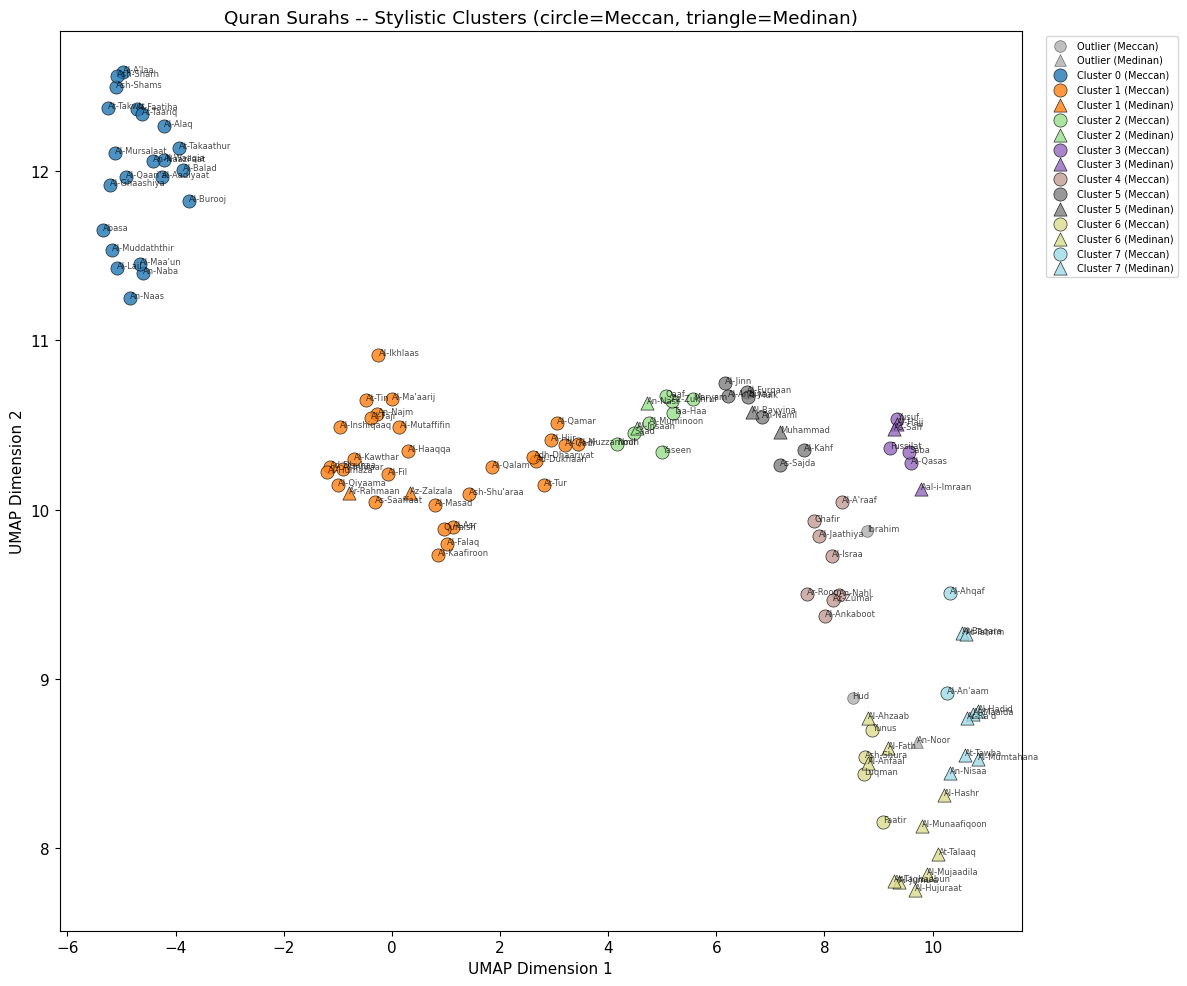

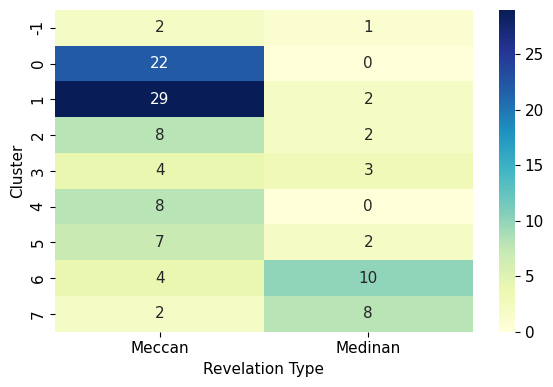

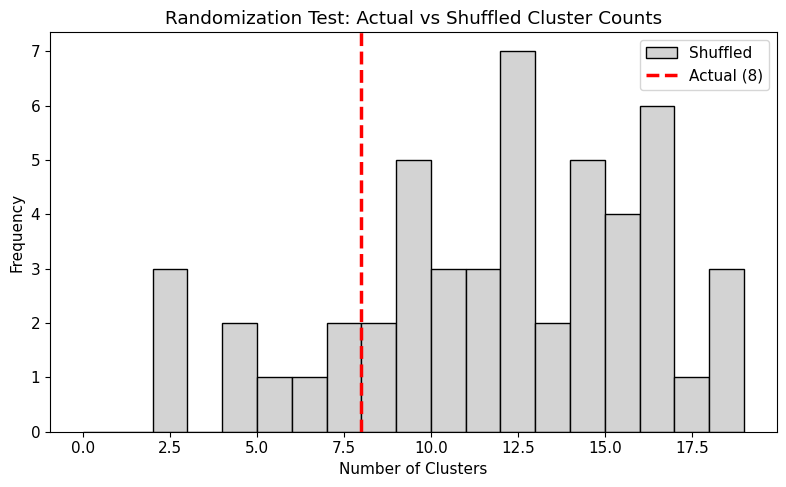

Figures saved to output/figures/


In [8]:
# CELL 8 -- Figures
fig, ax = plt.subplots(figsize=(12, 10))
unique_labels = sorted(set(hdbscan_labels))
n_clust_plot = len([l for l in unique_labels if l >= 0])
colors = plt.cm.tab20(np.linspace(0, 1, max(n_clust_plot, 1)))

markers = {"Meccan": "o", "Medinan": "^"}
for label in unique_labels:
    lab_mask = np.array(hdbscan_labels) == label
    for rtype, mk in markers.items():
        rmask = lab_mask & (cluster_df["revelation_type"].values == rtype)
        if not rmask.any():
            continue
        if label == -1:
            ax.scatter(umap_2d[rmask, 0], umap_2d[rmask, 1], c="gray", marker=mk, s=70, alpha=0.5,
                      label=f"Outlier ({rtype})" if label == -1 else None, edgecolors="black", linewidth=0.5)
        else:
            c = colors[label % len(colors)]
            ax.scatter(umap_2d[rmask, 0], umap_2d[rmask, 1], c=[c], marker=mk, s=90, alpha=0.8,
                      edgecolors="black", linewidth=0.5,
                      label=f"Cluster {label} ({rtype})" if rmask.sum() > 0 else None)

# annotate each surah with its english name
for i, snum in enumerate(surah_numbers_sorted):
    ax.annotate(name_lookup[snum], (umap_2d[i, 0], umap_2d[i, 1]), fontsize=6, alpha=0.7)

ax.set_xlabel("UMAP Dimension 1"); ax.set_ylabel("UMAP Dimension 2")
ax.set_title("Quran Surahs -- Stylistic Clusters (circle=Meccan, triangle=Medinan)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quran_umap_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

# Cluster vs revelation-type heatmap
fig, ax = plt.subplots(figsize=(6, max(4, len(crosstab) * 0.4)))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_xlabel("Revelation Type"); ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quran_cluster_vs_revelation.png", dpi=300, bbox_inches="tight")
plt.show()

# Randomization test histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(random_cluster_counts, bins=range(0, max(random_cluster_counts + [n_clusters]) + 2),
        color="lightgray", edgecolor="black", label="Shuffled")
ax.axvline(n_clusters, color="red", linewidth=2.5, linestyle="--", label=f"Actual ({n_clusters})")
ax.set_xlabel("Number of Clusters"); ax.set_ylabel("Frequency"); ax.legend()
ax.set_title("Randomization Test: Actual vs Shuffled Cluster Counts")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "quran_randomization_test.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figures saved to output/figures/")

## Step 7 — Report

Writes a summary with the caveats built in, so the numbers don't get
read without the necessary context.

In [9]:
# CELL 9 -- Final report
report_path = REPORTS_DIR / "quran_analysis_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("QURAN SURAH STYLISTIC CLUSTERING -- SUMMARY\n")
    f.write("=" * 70 + "\n\n")

    f.write("METHOD\n" + "-" * 40 + "\n")
    f.write("  Same pipeline as the pre-Islamic poetry paper: each ayah\n")
    f.write("  embedded with Arabic-SBERT-100K, averaged per surah, then\n")
    f.write("  UMAP + HDBSCAN clustering on the 114 surah-level vectors.\n\n")

    f.write("DATASET\n" + "-" * 40 + "\n")
    f.write(f"  Surahs: {len(surah_df)}\n")
    f.write(f"  Ayat: {len(ayah_df)}\n")
    f.write(f"  Meccan: {(surah_df['revelation_type'] == 'Meccan').sum()}, "
            f"Medinan: {(surah_df['revelation_type'] == 'Medinan').sum()}\n\n")

    f.write("SIMILARITY\n" + "-" * 40 + "\n")
    for k, v in sim_stats.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nCLUSTERING\n" + "-" * 40 + "\n")
    for k, v in cluster_metrics.items():
        f.write(f"  {k}: {v}\n")

    f.write("\nMECCAN/MEDINAN ALIGNMENT\n" + "-" * 40 + "\n")
    f.write(f"  Adjusted Rand Index vs Meccan/Medinan: {ari_vs_revelation:.3f}\n")
    f.write("  (0 = clusters unrelated to revelation period, 1 = perfect match)\n")
    f.write("\n  Per-cluster purity:\n")
    f.write(purity_df.to_string(index=False) + "\n")

    f.write("\nRANDOMIZATION TEST\n" + "-" * 40 + "\n")
    f.write(f"  Actual clusters: {randomization_summary['actual_clusters']}\n")
    f.write(f"  Shuffled mean: {randomization_summary['mean_clusters_shuffled']:.1f} "
            f"+/- {randomization_summary['std_clusters_shuffled']:.1f} "
            f"(over {randomization_summary['n_shuffles']} shuffles)\n")

    f.write("\nWHAT THIS DOES AND DOES NOT SHOW\n" + "-" * 40 + "\n")
    f.write("  - This measures WRITING-STYLE similarity/difference between\n")
    f.write("    surahs, and checks if that lines up with the already-known\n")
    f.write("    Meccan/Medinan classification (a low ARI vs. Meccan/Medinan\n")
    f.write("    just means clusters follow some OTHER pattern, not that\n")
    f.write("    they are meaningless).\n")
    f.write("  - It does NOT determine authorship. Single authors commonly\n")
    f.write("    show large stylistic shifts across years/contexts; shared\n")
    f.write("    style across decades is also common. Clustering alone\n")
    f.write("    cannot distinguish between these explanations.\n")
    f.write("  - The randomization test only tells you whether the observed\n")
    f.write("    cluster structure exceeds what noise alone would produce --\n")
    f.write("    it does not speak to WHY that structure exists.\n")

print(f"Report written to {report_path}")
print()
print(open(report_path, encoding="utf-8").read())

Report written to output\reports\quran_analysis_report.txt

QURAN SURAH STYLISTIC CLUSTERING -- SUMMARY

METHOD
----------------------------------------
  Same pipeline as the pre-Islamic poetry paper: each ayah
  embedded with Arabic-SBERT-100K, averaged per surah, then
  UMAP + HDBSCAN clustering on the 114 surah-level vectors.

DATASET
----------------------------------------
  Surahs: 114
  Ayat: 6236
  Meccan: 86, Medinan: 28

SIMILARITY
----------------------------------------
  n_surahs: 114
  n_pairs: 6441
  mean: 0.9315038919448853
  std: 0.06681162863969803
  min: 0.7354738712310791
  max: 0.9999815225601196
  median: 0.9570183753967285

CLUSTERING
----------------------------------------
  n_clusters: 8
  n_outliers: 3
  silhouette: 0.715386152267456

MECCAN/MEDINAN ALIGNMENT
----------------------------------------
  Adjusted Rand Index vs Meccan/Medinan: 0.107
  (0 = clusters unrelated to revelation period, 1 = perfect match)

  Per-cluster purity:
 cluster  size majority_

## Done

Output in `output/`:
- `output/figures/` — UMAP scatter (labeled by Meccan/Medinan), cluster
  heatmap, randomization histogram
- `output/tables/` — surah metadata, cluster assignments, purity scores
- `output/reports/quran_analysis_report.txt` — full summary with the
  caveats included

**Reading the result:** if the Adjusted Rand Index (in the report) is
high, clusters mostly track Meccan/Medinan — an expected, already-known
pattern, not a new discovery. If it's low, clusters are picking up on
something else (theme, length, subject matter, etc.) — worth looking at
which surahs land together to see what they share. Either way, this is a
description of stylistic patterns, not a determination of authorship.